#CAP 6315 - Social Networks and Big Data Analytics
## Project Part #2
### Jordan Winemiller - Z23962588

[*Colab Project Link*](https://colab.research.google.com/drive/1qGJSBkJfJrQsiWbSuAR0w9ISzZR-hiyj)

[*GitHub Project Link*](https://github.com/jmwinemiller/cap-6315-project)

[*Overleaf Report*](https://www.overleaf.com/read/xrsbhmvfwvqc#2ab9ba)



This project with be using the [*Twitch Social Network*](https://snap.stanford.edu/data/twitch-social-networks.html) datasets, and be examining the Brazilian Portuguese language stream for our network.

In [30]:
# Setup and Imports
import random
import os
import zipfile

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml.feature import (
    VectorAssembler,
)
from pyspark.ml.tuning import (
    CrossValidator,
)
from pyspark.sql import (
    SparkSession,
    Window,
)
import pyspark.sql.functions as F
import pyspark.sql.types as T
import seaborn as sns


SEED = 1234
LANG = "PTBR"
PATH = os.getcwd()
DATA_PATH = os.path.join(
    PATH,
    "twitch",
    LANG,
)


random.seed(SEED)
np.random.seed(SEED)

### Importing the data and creating PySpark session

#### Unzipping archive file

In [31]:
arhive_file = "twitch.zip"
with zipfile.ZipFile(os.path.join(PATH, arhive_file), "r") as archive_obj:
  archive_obj.extractall(PATH)

#### Creating the Spark Session and Loading the Dataset

In [32]:
spark = SparkSession.builder \
    .appName("ProjectPart-2") \
    .getOrCreate()

In [33]:
df = spark.read.csv(
    path=os.path.join(DATA_PATH, f"musae_{LANG}_edges.csv"),
    header=True,
    inferSchema=True,
)

#### Creating Graph with NetworkX

In [34]:
G = nx.Graph()

edges = df.collect()
G.add_edges_from([
    (row["from"], row["to"])
    for row in edges
])

#### Create a Spark Dataframe with the Following Network Features:
- Degree Centrality
- Betweenness Centrality
- Closeness Centrality
- Eigenvector Centrality
- PageRank

In [35]:
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)
pagerank = nx.pagerank(G)

Test to Make Sure All Measures are in the Same Order

In [36]:
def check_order(dict_1, dict_2):
    """Check if two dictionaries have the same keys in the same order.

    :param dict_1: First dictionary to check
    :param dict_2: Second dictionary to check
    :return: True if the dictionaries have the same keys in the same order
    """
    return list(dict_1.keys()) == list(dict_2.keys())

print(
    f"Is same order for Degree and Betweenness Centralities:"
    + " "
    f"{check_order(degree, betweenness)}")
print(
    f"Is same order for Degree and Closeness Centralities:"
    + " "
    f"{check_order(degree, closeness)}")
print(
    f"Is same order for Degree and Eigenvector Centralities:"
    + " "
    f"{check_order(degree, eigenvector)}")
print(
    f"Is same order for Degree Centrality and PageRank:"
    + " "
    f"{check_order(degree, pagerank)}")

Is same order for Degree and Betweenness Centralities: True
Is same order for Degree and Closeness Centralities: True
Is same order for Degree and Eigenvector Centralities: True
Is same order for Degree Centrality and PageRank: True


Create Graph Centrality Spark Dataframe

In [37]:
schema = T.StructType([
    T.StructField("node", T.IntegerType(), True),
    T.StructField("degree", T.DoubleType(), True),
    T.StructField("betweenness", T.DoubleType(), True),
    T.StructField("closeness", T.DoubleType(), True),
    T.StructField("eigenvector", T.DoubleType(), True),
    T.StructField("pagerank", T.DoubleType(), True),
])

data = zip(
    degree.keys(),
    degree.values(),
    betweenness.values(),
    closeness.values(),
    eigenvector.values(),
    pagerank.values(),
)

g_df = spark.createDataFrame(
    data,
    schema=schema,
)

g_df.show(5)

+----+--------------------+--------------------+-------------------+--------------------+--------------------+
|node|              degree|         betweenness|          closeness|         eigenvector|            pagerank|
+----+--------------------+--------------------+-------------------+--------------------+--------------------+
|   0|0.001046572475143...|2.039880322525145...| 0.3489136388533869| 0.00122434977159675|1.080941325389477...|
|  92|0.023547880690737835|0.003121403530497...| 0.4241011984021305|0.008612204739140653|9.339108322930132E-4|
| 428| 0.17373103087388803|0.021980008718637752| 0.5219885277246654| 0.11271156026302646|0.004689928434443929|
|   1|0.001569858712715...|  4.6043920125031E-7|0.35025659824046923|0.001553476206518...|1.148048466908686...|
| 689| 0.07430664573521717|0.002383681268152517|0.47870741482965934|0.061066921770705156|0.001896727185355...|
+----+--------------------+--------------------+-------------------+--------------------+--------------------+
o

#### Join Node Attributes with the Network Features

*Node Attributes*
- Views
- Days
- Mature

*Target Class*
- Partner

Load Node Attribute Dataframe

In [38]:
att_df = spark.read.csv(
    path=os.path.join(DATA_PATH, f"musae_{LANG}_target.csv"),
    header=True,
    inferSchema=True
)

att_df.show(5)

+---------+----+------+------+-------+------+
|       id|days|mature| views|partner|new_id|
+---------+----+------+------+-------+------+
| 44891403|1943| false|929459|   true|  1706|
| 61180621|1633| false| 11194|  false|  1273|
|145109685| 632| false|  2850|  false|   313|
|122121521| 906|  true|  3422|  false|  1570|
|189445819| 267| false|    71|  false|   800|
+---------+----+------+------+-------+------+
only showing top 5 rows


Join Graph Attributes and Node Attributes Dataframes

In [39]:
join_df = g_df.join(
    other=att_df,
    on=[g_df.node == att_df.new_id],
    how="inner",
)
join_df = join_df.drop("id", "new_id")

join_df.show(5)

+----+--------------------+--------------------+-------------------+--------------------+--------------------+----+------+-------+-------+
|node|              degree|         betweenness|          closeness|         eigenvector|            pagerank|days|mature|  views|partner|
+----+--------------------+--------------------+-------------------+--------------------+--------------------+----+------+-------+-------+
|   0|0.001046572475143...|2.039880322525145...| 0.3489136388533869| 0.00122434977159675|1.080941325389477...|1601| false|    475|  false|
|  92|0.023547880690737835|0.003121403530497...| 0.4241011984021305|0.008612204739140653|9.339108322930132E-4|2003|  true|  60988|   true|
| 428| 0.17373103087388803|0.021980008718637752| 0.5219885277246654| 0.11271156026302646|0.004689928434443929| 845|  true| 552640|   true|
|   1|0.001569858712715...|  4.6043920125031E-7|0.35025659824046923|0.001553476206518...|1.148048466908686...|1561| false|    345|  false|
| 689| 0.07430664573521717|

#### Define the Target Variable as *partner*

**NOTE:** Since the only categorical feature *mature* is a boolean type the
*StringIndexer* or *OneHotEncoder* was NOT needed for creating the features.

In [40]:
target_column = "partner"

feature_columns = [
    "degree",
    "betweenness",
    "closeness",
    "eigenvector",
    "pagerank",
    "days",
    "mature",
    "views",
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)
feature_df = assembler.transform(join_df)

feature_df.select("features", target_column).show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------+-------+
|features                                                                                                                      |partner|
+------------------------------------------------------------------------------------------------------------------------------+-------+
|[0.0010465724751439038,2.0398803225251453E-6,0.3489136388533869,0.00122434977159675,1.0809413253894772E-4,1601.0,0.0,475.0]   |false  |
|[0.023547880690737835,0.0031214035304972156,0.4241011984021305,0.008612204739140653,9.339108322930132E-4,2003.0,1.0,60988.0]  |true   |
|[0.17373103087388803,0.021980008718637752,0.5219885277246654,0.11271156026302646,0.004689928434443929,845.0,1.0,552640.0]     |true   |
|[0.0015698587127158557,4.6043920125031E-7,0.35025659824046923,0.0015534762065188574,1.1480484669086864E-4,1561.0,0.0,345.0]   |false  |
|[0.07430664573521717,0.00238368126815251

#### Calculate the Total Number of Partners and Non-Partners

In [41]:
print(
    f"Non-Partnered Count: {feature_df.filter(~F.col(target_column)).count()}")
print(f"Partnered Count: {feature_df.filter(F.col(target_column)).count()}")

Non-Partnered Count: 1633
Partnered Count: 279


#### Partner and Non-Partner Dataset Balance

> The dataset is comprised of $1,633$ non-partnered streamer which makes up
> around $85.4\%$ of the data. So, there is a large imbalance in the dataset
> for the partner class that favors the non-partnered streamers.

#### Numerical Feature Boxplots

The Boxplots for the Numerical Features are Grouped by Partner Status

In [42]:
def numeric_boxplots(df, feature, target, title, x_label):
    """Shows the boxplot for a numerical feature grouped by the target column.

    :param df: PySpark Dataframe
    :param feature: Name of the feature column
    :param target: Name of the target column
    :param title: Title of the plot
    :param x_label: Label for the x-axis
    """
    plt.figure(figsize=(15, 9))
    sns.boxplot(
        x=df.select(feature).rdd.map(lambda x: x[0]).collect(),
        hue=df.select(target).rdd.map(lambda x: x[0]).collect(),
    )
    plt.title(title)
    plt.xlabel(x_label)
    plt.show()

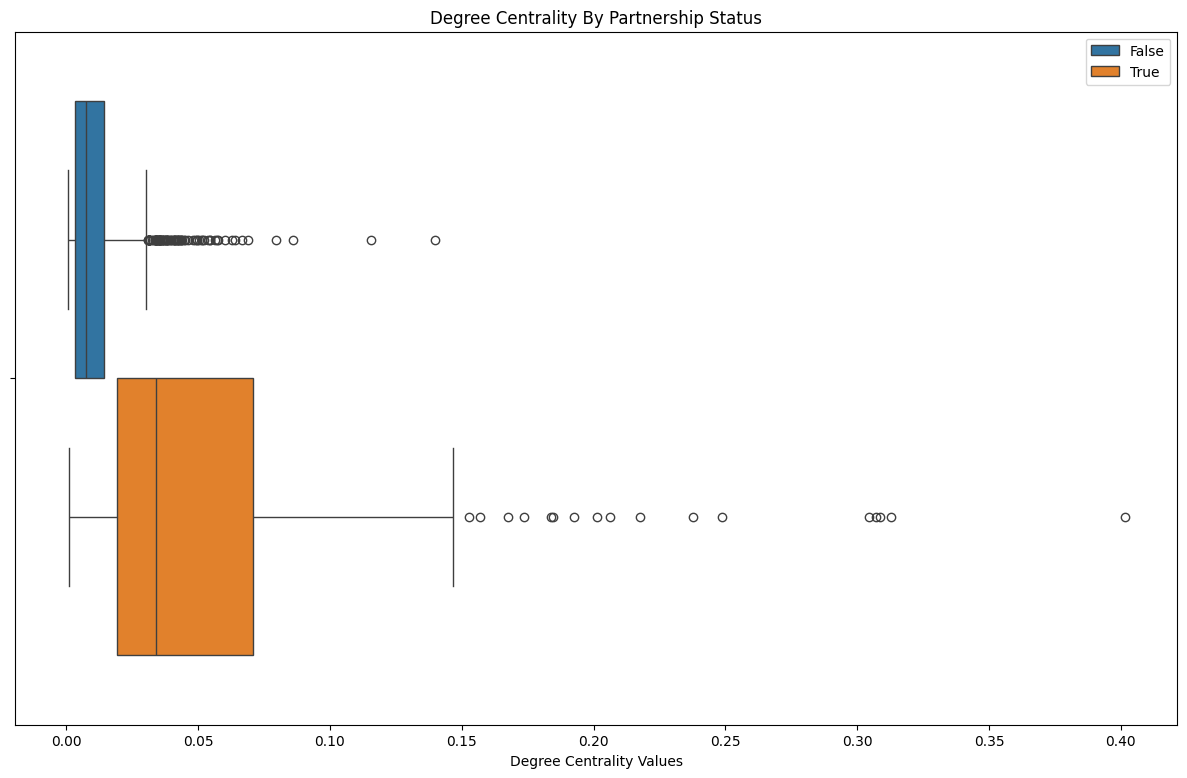

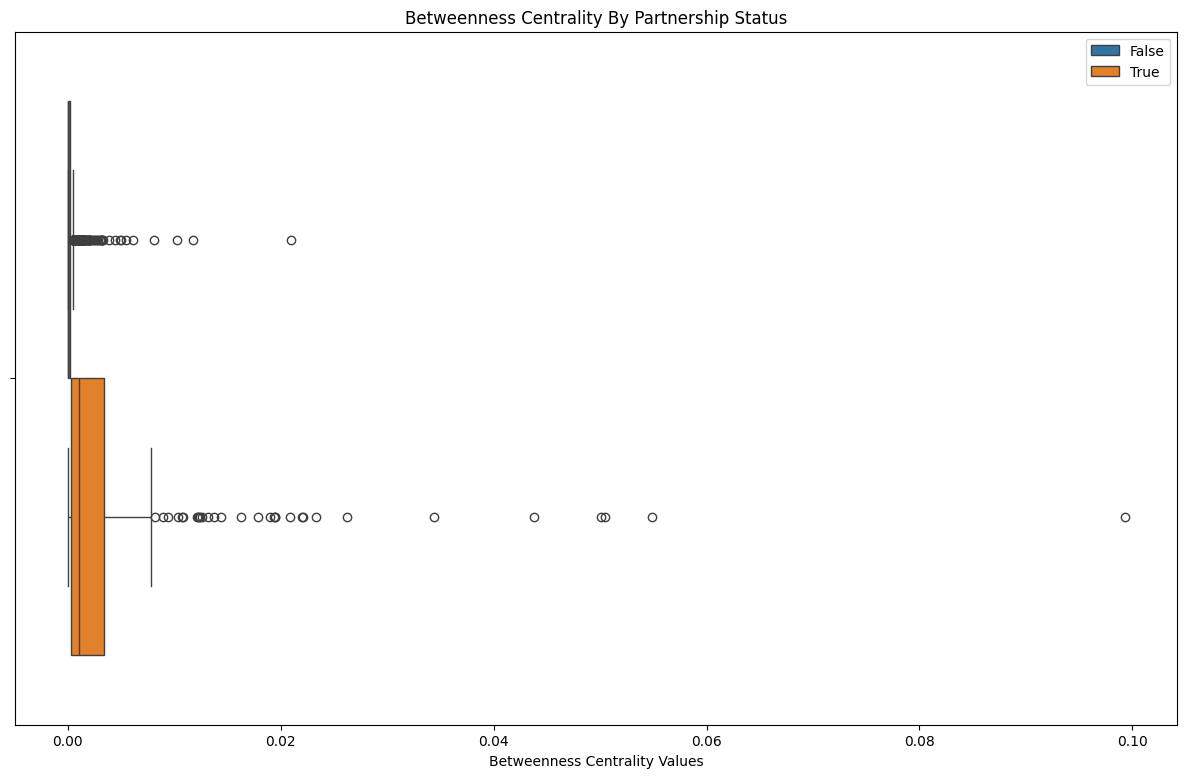

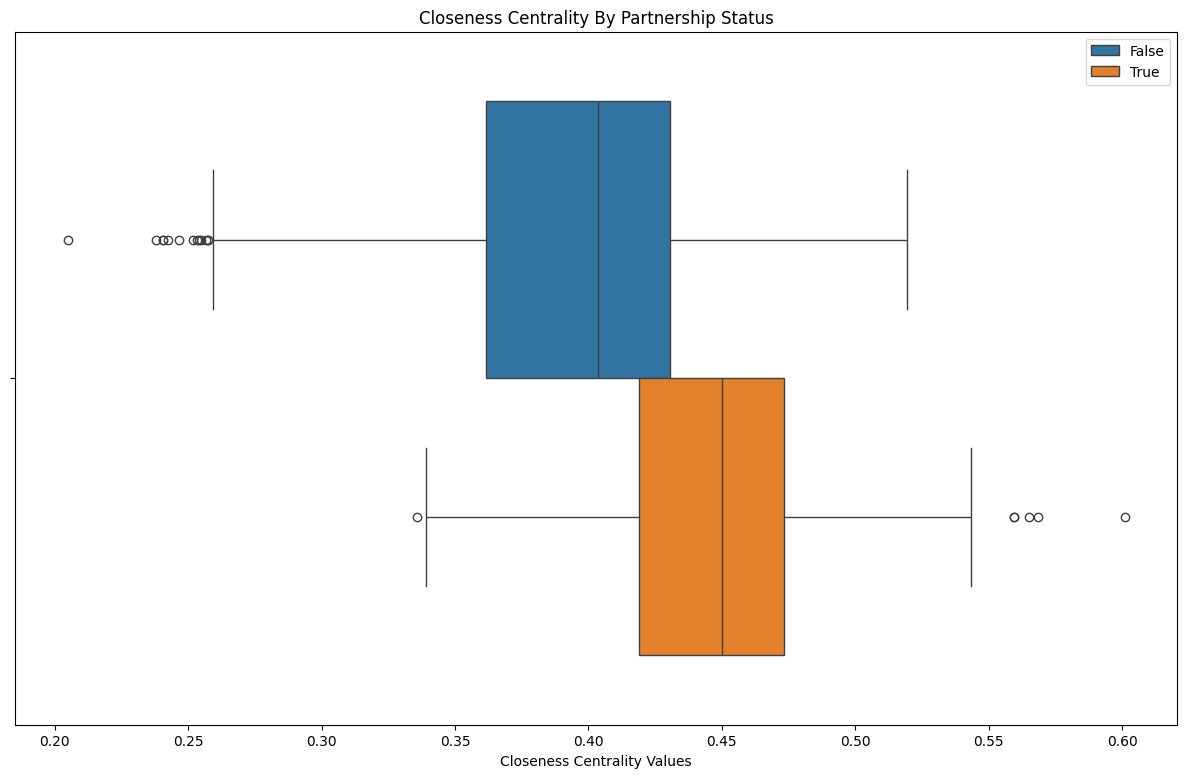

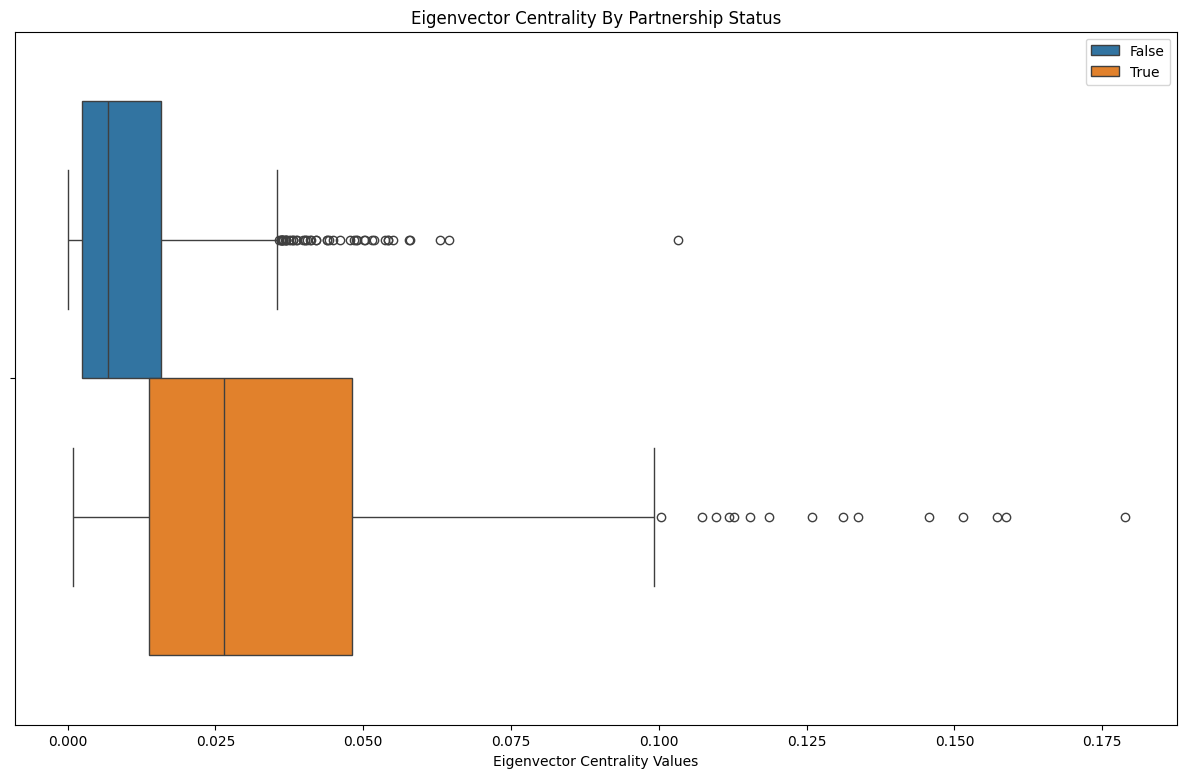

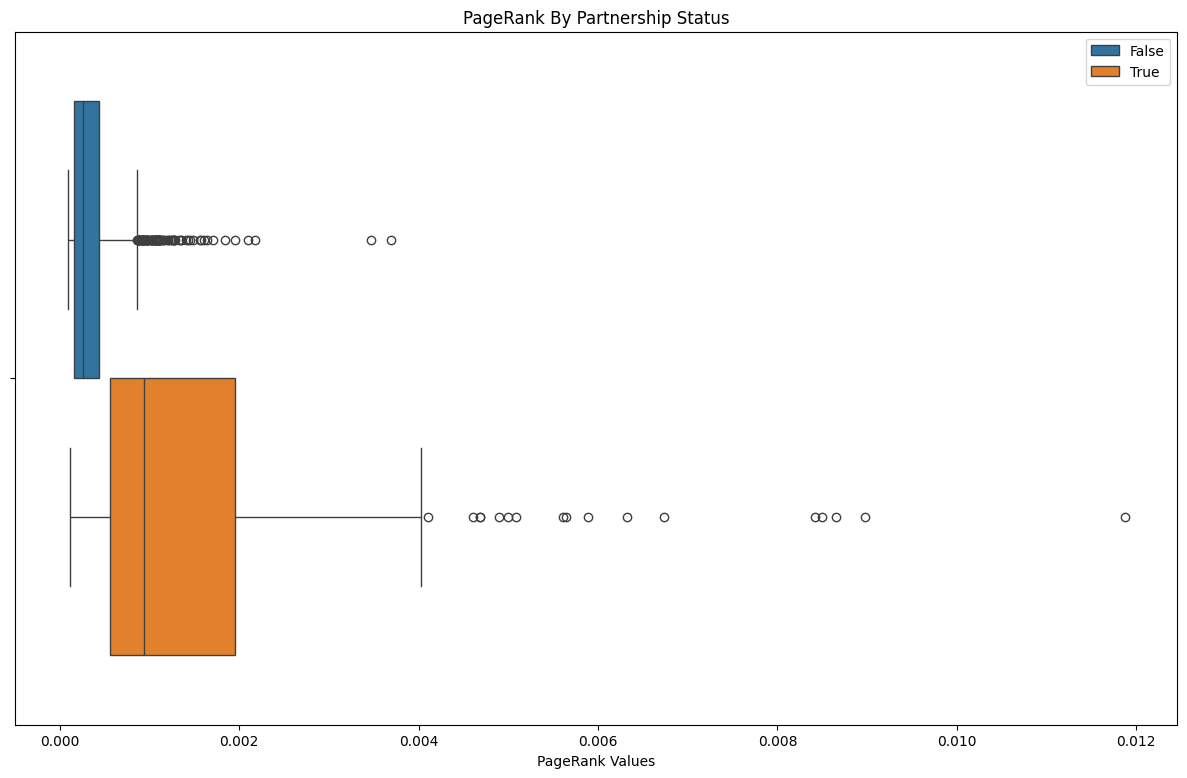

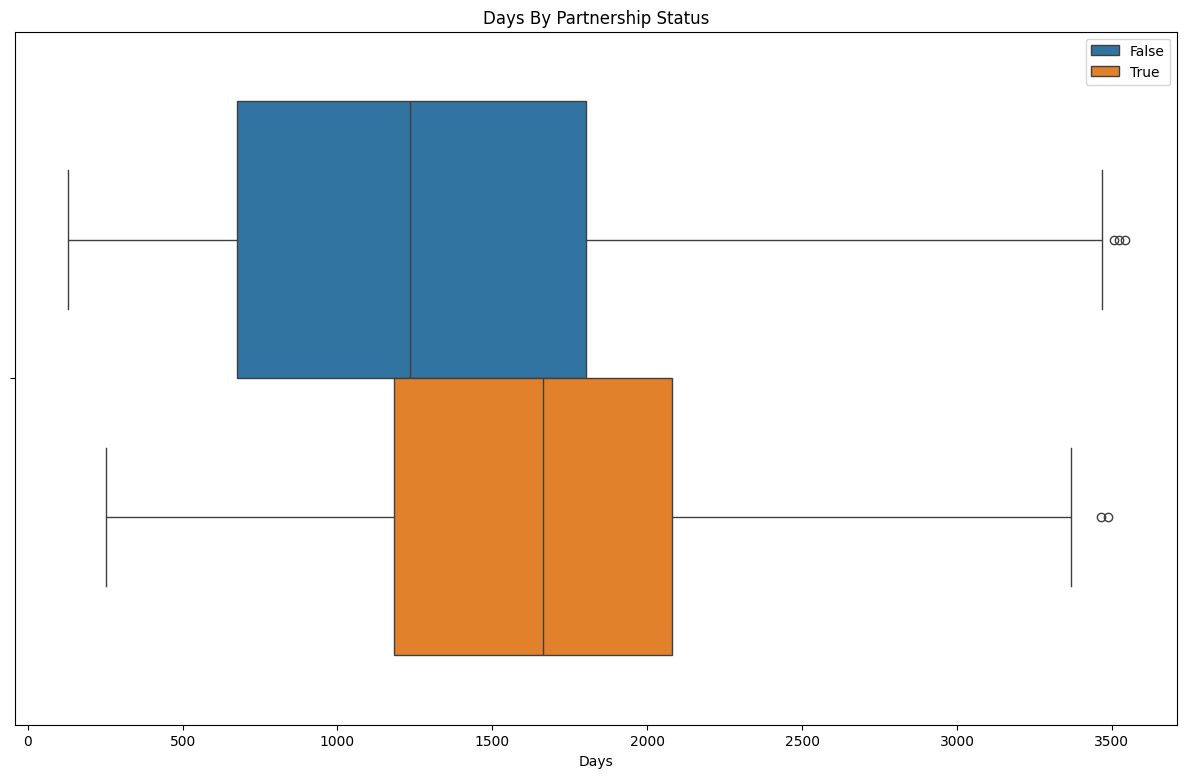

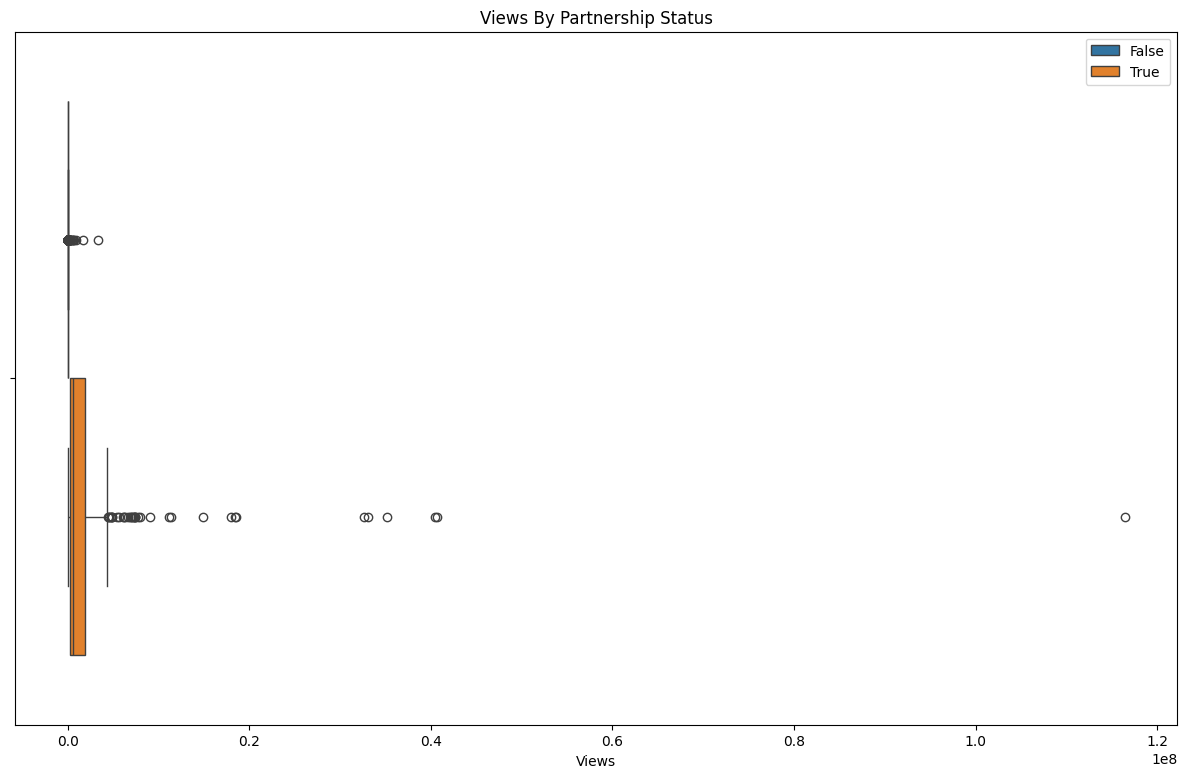

In [43]:
cent_boxplots = feature_columns[:4]

for feature in cent_boxplots:
    numeric_boxplots(
        df=feature_df,
        feature=feature,
        target=target_column,
        title=f"{feature.title()} Centrality By Partnership Status",
        x_label=f"{feature.title()} Centrality Values",
    )
    # plt.figure(figsize=(15, 9))
    # sns.boxplot(
    #     x=feature_df.select(feature).rdd.map(lambda x: x[0]).collect(),
    #     hue=feature_df.select("partner").rdd.map(lambda x: x[0]).collect(),
    # )
    # plt.title(f"{feature.title()} Centrality By Partnership Status")
    # plt.xlabel(f"{feature.title()} Centrality Values")
    # plt.show()

num_boxplots = [
    "pagerank",
    "days",
    "views",
]

for feature in num_boxplots:
    name = "PageRank" if feature == "pagerank" else feature.title()
    x_label = f"{name} Values" if feature == "pagerank" else name
    numeric_boxplots(
        df=feature_df,
        feature=feature,
        target=target_column,
        title=f"{name} By Partnership Status",
        x_label=x_label,
    )
    # plt.figure(figsize=(15, 9))
    # sns.boxplot(
    #     x=feature_df.select(feature).rdd.map(lambda x: x[0]).collect(),
    #     hue=feature_df.select("partner").rdd.map(lambda x: x[0]).collect(),
    # )
    # name = "PageRank" if feature == "pagerank" else feature.title()
    # x_label = f"{name} Values" if feature == "pagerank" else name
    # plt.title(f"{name} By Partnership Status")
    # plt.xlabel(x_label)
    # plt.show()

#### Categorical Features Bar Chart

The Bar Charts for the Categorical Features are Grouped by Partner Status

+------+-------+-----+
|mature|partner|count|
+------+-------+-----+
|  true|  false|  560|
|  true|   true|  101|
| false|  false| 1073|
| false|   true|  178|
+------+-------+-----+



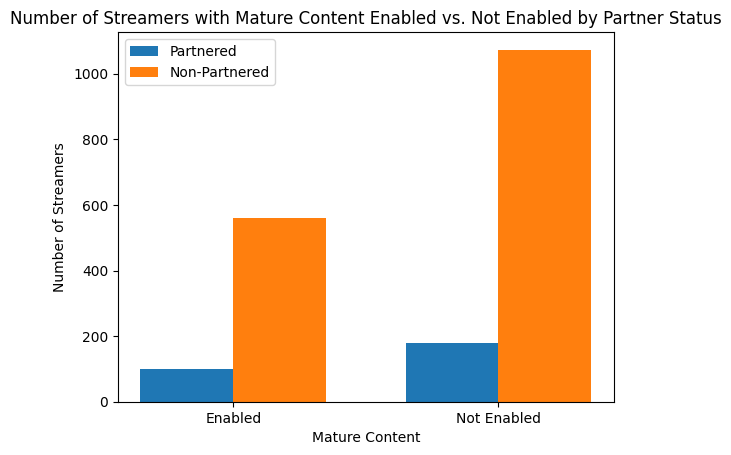

In [44]:
feature_df.groupBy("mature", "partner").count().show()

x_label = ["Enabled", "Not Enabled"]
x_ind = np.arange(len(x_label))
y_1 = feature_df.filter(F.col(target_column)) \
    .groupBy("mature").count().rdd.map(lambda x: x[1]).collect()
y_2 = feature_df.filter(~F.col(target_column)) \
    .groupBy("mature").count().rdd.map(lambda x: x[1]).collect()
width = 0.35

fig, ax = plt.subplots()
ax.bar(
    x=x_ind - width / 2,
    height=y_1,
    width=width,
    label="Partnered",
)
ax.bar(
    x=x_ind + width / 2,
    height=y_2,
    width=width,
    label="Non-Partnered",
)
ax.set_ylabel("Number of Streamers")
ax.set_title(
    "Number of Streamers with Mature Content Enabled vs. Not Enabled by Partner"
    + " "
    + "Status")
ax.set_xticks(x_ind)
ax.set_xticklabels(x_label)
ax.set_xlabel("Mature Content")
ax.legend()

#### Feature Discussion on Visualizations

> Based on the visualizations, the features that have a visible difference
> where mean ($Q2$) of one group is above ($Q3$) or below ($Q1$) of the other
> group for numerical features or double the streamers of the other group for
> categorical features between partner and non-partner streamers are:
> - Degree Centrality
> - Betweenness Centrality
> - Closeness Centrality
> - Eigenvector Centrality
> - PageRank
> - Views
> - Mature Content
>
> The numerical feature *Days* was the only feature that did not show a massive
> difference that we were looking for above.

*Note:* This is before the data imbalanced is handled.

#### Handling the Class Imbalance

In [45]:
minor_df = feature_df.filter(F.col(target_column))
major_df = feature_df.filter(~F.col(target_column))

major_sampled = major_df.sample(
    fraction=minor_df.count() / major_df.count(),
    seed=SEED,
)

print(f"Minority Class Count: {minor_df.count()}")
print(f"Majority Sampled Count: {major_sampled.count()}")

balanced_df = minor_df.union(major_sampled)
balanced_df.groupBy(target_column).count().show()

Minority Class Count: 279
Majority Sampled Count: 294
+-------+-----+
|partner|count|
+-------+-----+
|   true|  279|
|  false|  294|
+-------+-----+



#### Split the Data into Training and Testing Sets

- This experiment is using an $80\%$ Training to $20\%$ Testing Split
- The Target Column Needed to be Converted to a Numerical Value

In [46]:
shuffled_df = balanced_df \
    .withColumn("partner", F.col("partner").cast(T.IntegerType())) \
    .orderBy(F.rand(seed=SEED))

shuffled_df.show(5)

+----+--------------------+--------------------+-------------------+--------------------+--------------------+----+------+------+-------+--------------------+
|node|              degree|         betweenness|          closeness|         eigenvector|            pagerank|days|mature| views|partner|            features|
+----+--------------------+--------------------+-------------------+--------------------+--------------------+----+------+------+-------+--------------------+
| 887|0.016221873364730507|0.001124225028057851| 0.4246666666666667|0.013389895791342594|5.468729589767586E-4| 751|  true|560606|      0|[0.01622187336473...|
|  21|0.012035583464154894|5.343165711693281E-5| 0.4169757800567314|0.012221696425284258|3.523741879322434...|1451|  true|  8728|      0|[0.01203558346415...|
| 345|0.004709576138147567| 4.21831282408123E-5|0.37640338782745714|0.003028815088868...|2.140813055632411E-4|1661|  true|  6938|      0|[0.00470957613814...|
|1418|0.004709576138147567|1.116215687569845..

In [47]:
train_df, test_df = shuffled_df.randomSplit(
    weights=[0.8, 0.2],
    seed=SEED,
)
print(f"Training Set Size: {train_df.count()}")
print(f"Testing Set Size: {test_df.count()}")

Training Set Size: 453
Testing Set Size: 120


#### Train a Logistic Regression Model

Using PySpark Perform a **5-fold** Cross-Validation

In [48]:
k = 5
folds = train_df.randomSplit(
    weights=[1 / k] * k,
    seed=SEED,
)

acc_scores = []
f1_scores  = []
precision_scores = []
recall_scores = []

for i in range(k):
    test_fold = folds[i]
    train_fold = spark.createDataFrame(
        spark.sparkContext.emptyRDD(),
        train_df.schema,
    )

    for j in range(k):
        if j != i:
            train_fold = train_fold.union(folds[j])

    lr_mod = LogisticRegression(
        featuresCol="features",
        labelCol=target_column,
    ).fit(train_fold)
    preds = lr_mod.transform(test_fold)

    acc_evaluator = MulticlassClassificationEvaluator(
        labelCol=target_column,
        predictionCol="prediction",
        metricName="accuracy",
    )
    f1_evaluator = MulticlassClassificationEvaluator(
        labelCol=target_column,
        predictionCol="prediction",
        metricName="f1",
    )
    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol=target_column,
        predictionCol="prediction",
        metricName="precisionByLabel",
    )
    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol=target_column,
        predictionCol="prediction",
        metricName="recallByLabel",
    )

    acc_scores.append(acc_evaluator.evaluate(preds))
    f1_scores.append(f1_evaluator.evaluate(preds))
    precision_scores.append(precision_evaluator.evaluate(preds))
    recall_scores.append(recall_evaluator.evaluate(preds))

#### Report the Average Cross-Validation Metrics

- Accuracy
- F1 Score
- Precision
- Recall

In [49]:
print(f"Average Accuracy: {sum(acc_scores) / k}")
print(f"Average F1 Score: {sum(f1_scores) / k}")
print(f"Average Precision: {sum(precision_scores) / k}")
print(f"Average Recall: {sum(recall_scores) / k}")

Average Accuracy: 0.9034604893263947
Average F1 Score: 0.9032815755432628
Average Precision: 0.8770457090501884
Average Recall: 0.9457367213402718


#### Train the Model

Train Model on the Whole Training Set and Generate Predictions on the Test Set

In [50]:
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="accuracy",
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="f1",
)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="precisionByLabel",
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="recallByLabel",
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol=target_column,
)
final_model = lr.fit(train_df)
preds = final_model.transform(test_df)

#### Report Model Performance Metrics on the Test Set

- Accuracy
- F1 Score
- Precision
- Recall

In [51]:
print(f"Model Accuracy: {acc_evaluator.evaluate(preds)}")
print(f"Model F1 Score: {f1_evaluator.evaluate(preds)}")
print(f"Model Precision: {precision_evaluator.evaluate(preds)}")
print(f"Model Recall: {recall_evaluator.evaluate(preds)}")

Model Accuracy: 0.9083333333333333
Model F1 Score: 0.9081739130434783
Model Precision: 0.8769230769230769
Model Recall: 0.95


### Results

> The average metrics for Precision and Recall were a little higher for the
> k-folds cross-validation. The final model that was trained on the full
> training set outperformed the k-folds cross-validation method on Accuracy and
> the F1 score. This might be due to the small sample size once the class
> imbalance was handled.

#### Extension Example For Views

> When looking at the numerical feature *views* there is a major skewness. In
> order to fix this I reran the model were a **Log Transformation** $log(x+1)$
> was applied to the *views* feature.

Plots of the *Views* Numerical Feature with and without the log transformation

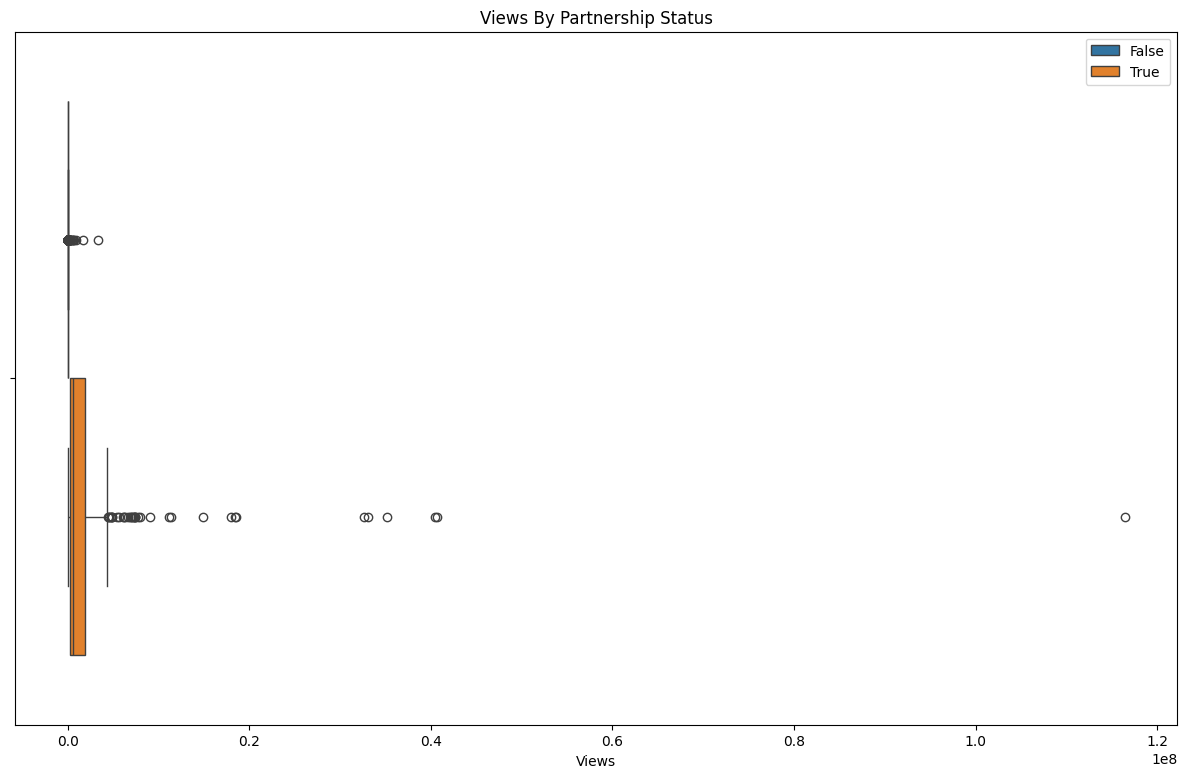

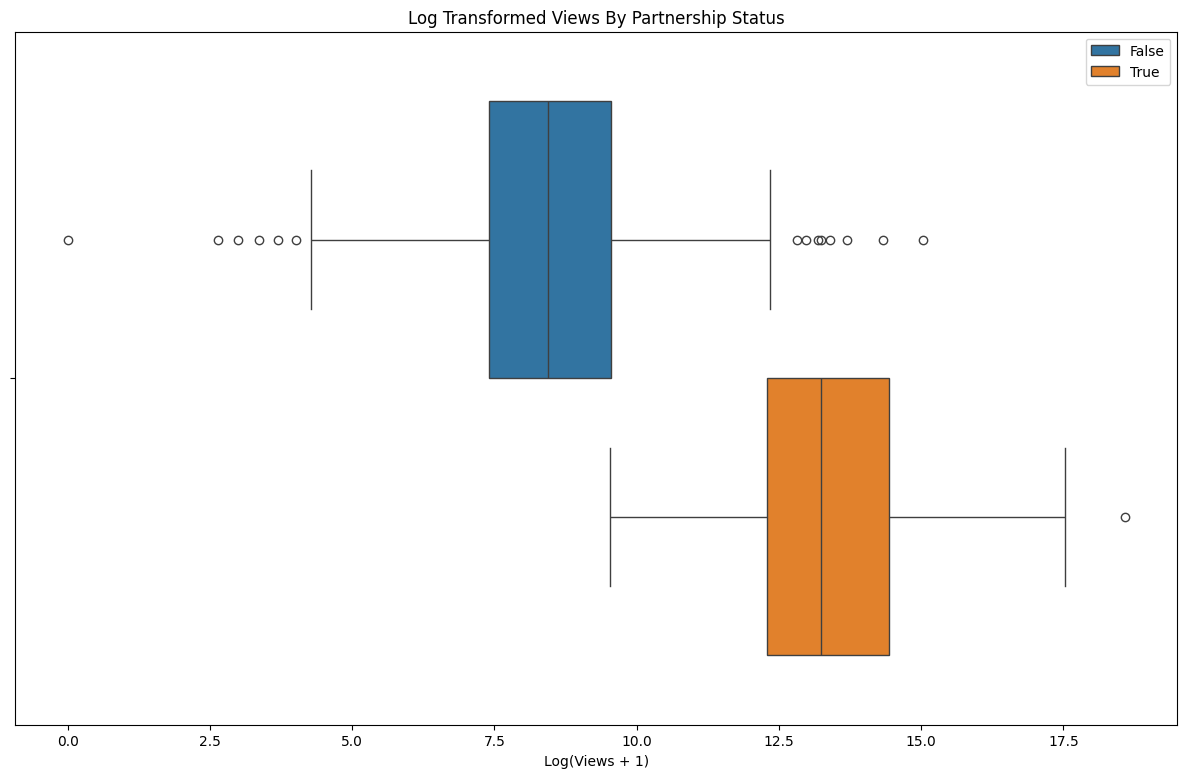

In [52]:
join_df = join_df.withColumn(
    "log_views", F.log(F.col("views") + 1))

numeric_boxplots(
    df=join_df,
    feature="views",
    target=target_column,
    title="Views By Partnership Status",
    x_label="Views",
)
numeric_boxplots(
    df=join_df,
    feature="log_views",
    target=target_column,
    title="Log Transformed Views By Partnership Status",
    x_label="Log(Views + 1)",
)


Adding the Transformed Column and Rebuilding the Features

In [53]:
log_train_df = train_df.withColumn(
    "log_views", F.log(F.col("views") + 1))
log_test_df = test_df.withColumn(
    "log_views", F.log(F.col("views") + 1))


feature_columns = [
    "degree",
    "betweenness",
    "closeness",
    "eigenvector",
    "pagerank",
    "days",
    "mature",
    "log_views",
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="log_features",
)
log_train_df = assembler.transform(log_train_df)
log_test_df = assembler.transform(log_test_df)

Rerunning the Final Model with New Features

In [54]:
log_lr = LogisticRegression(
    featuresCol="log_features",
    labelCol=target_column,
)
log_test_model = log_lr.fit(log_train_df)
log_preds = log_test_model.transform(log_test_df)

print(f"Model Accuracy: {acc_evaluator.evaluate(log_preds)}")
print(f"Model F1 Score: {f1_evaluator.evaluate(log_preds)}")
print(f"Model Precision: {precision_evaluator.evaluate(log_preds)}")
print(f"Model Recall: {recall_evaluator.evaluate(log_preds)}")

Model Accuracy: 0.9666666666666667
Model F1 Score: 0.9666574048346763
Model Precision: 0.9827586206896551
Model Recall: 0.95


#### Extra Metrics for the Paper

Clustering Coefficient and Connect Components

In [55]:
cc = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {cc}")

components = nx.number_connected_components(G)
print(f"Number of Connected Components: {components}")


Average Clustering Coefficient: 0.31989527466935147
Number of Connected Components: 1


Histograms of Centralities

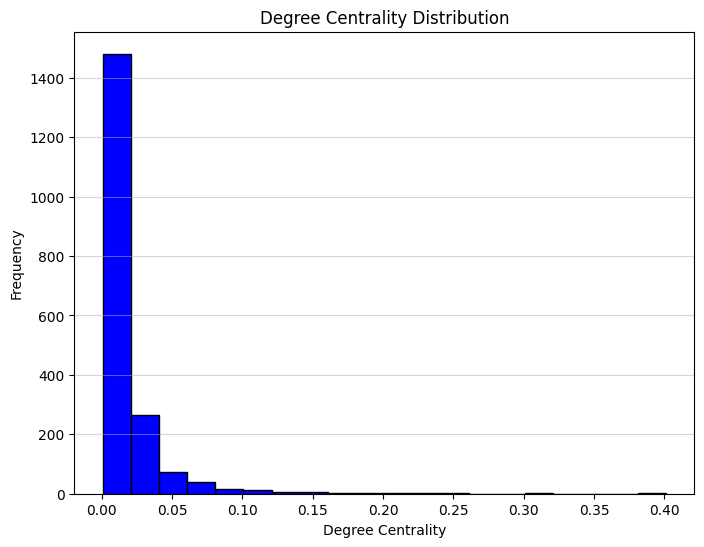

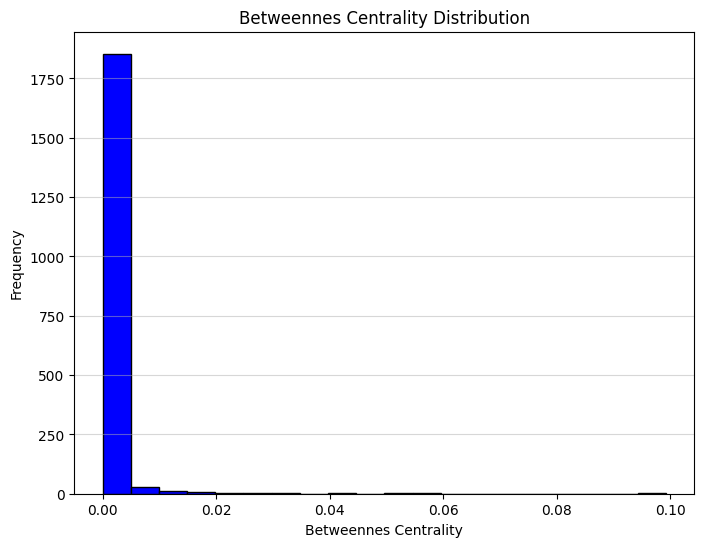

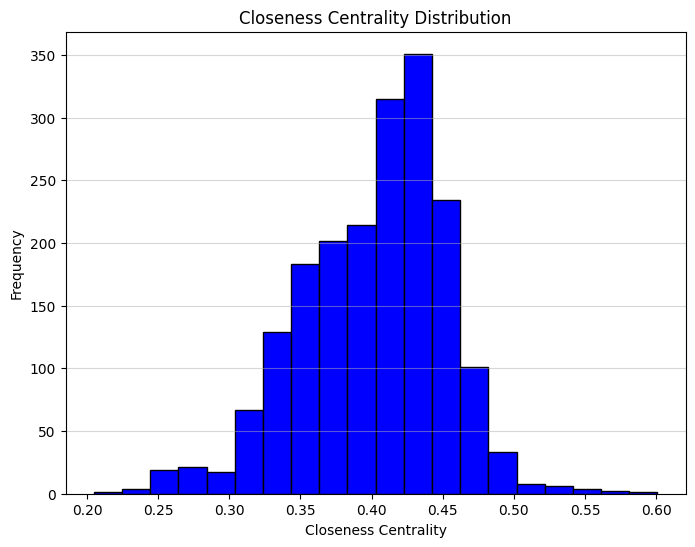

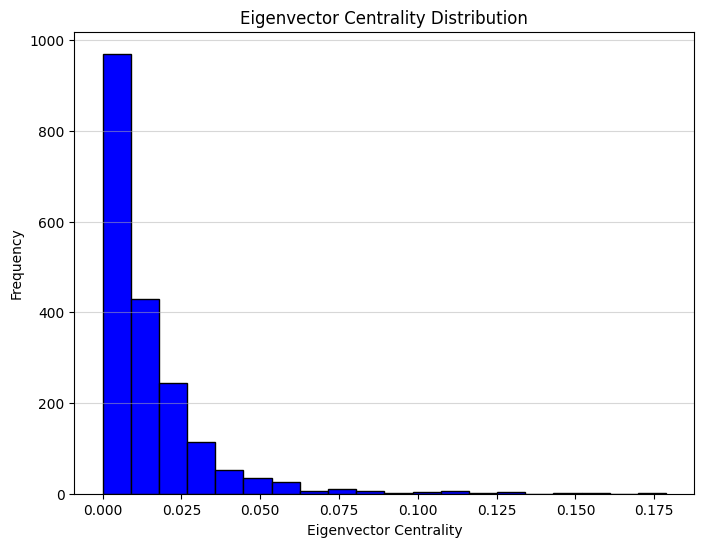

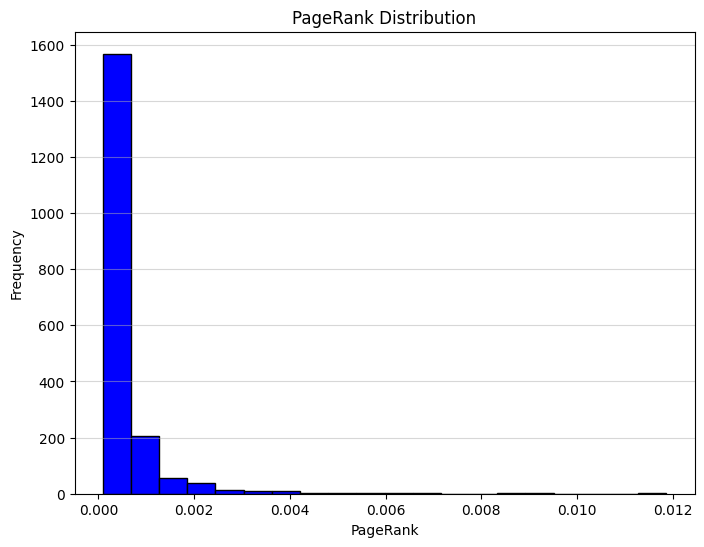

In [56]:
cent_list = [
    {"name": "degree", "val": list(degree.values())},
    {"name": "betweennes", "val": list(betweenness.values())},
    {"name": "closeness", "val": list(closeness.values())},
    {"name": "eigenvector", "val": list(eigenvector.values())},
    # {"name": "PageRank": pagerank},
]

for cent in cent_list:
    name = cent.get("name", "").title()
    vals = cent.get("val", [])
    plt.figure(figsize=(8, 6))
    plt.hist(vals, bins=20, color='blue', edgecolor='black')
    plt.title(f"{name} Centrality Distribution")
    plt.xlabel(f"{name} Centrality")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.5)
    plt.show()

plt.figure(figsize=(8, 6))
plt.hist(list(pagerank.values()), bins=20, color='blue', edgecolor='black')
plt.title(f"PageRank Distribution")
plt.xlabel(f"PageRank")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

### End of Project